<a href="https://colab.research.google.com/github/NhiLY120504/EcommerceRepurchasePrediction_ML/blob/main/RepurPredict-CateRecom_Preprocess%26FeatureEngineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# PREPROCESSING_1
import pandas as pd
import ast
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')
filter_path = '/content/drive/MyDrive/KLTN_dataset_filter'

df_transactions = pd.read_csv(os.path.join(filter_path, 'apparel_transactions.csv'))
df_products = pd.read_csv(os.path.join(filter_path, 'apparel_products.csv'))
df_customers = pd.read_csv(os.path.join(filter_path, 'apparel_customers.csv'))
df_clickstream = pd.read_csv(os.path.join(filter_path, 'apparel_clickstream.csv'))

print("Loaded 4 original filtered files.")

# Parse event_metadata (Clickstream)
def extract_product_id(metadata_str):
    if pd.isna(metadata_str):
        return np.nan
    try:
        parsed = ast.literal_eval(metadata_str)
        if isinstance(parsed, dict):
            return parsed.get('product_id', np.nan)
        return np.nan
    except Exception:
        return np.nan

df_clickstream['product_id_extracted'] = df_clickstream['event_metadata'].apply(extract_product_id)
print("Clickstream Table: Added column 'product_id_extracted'.")

# Drop event_metadata để giảm dung lượng
if "event_metadata" in df_clickstream.columns:
    df_clickstream.drop(columns=["event_metadata"], inplace=True)
    print("Clickstream Table: Dropped column 'event_metadata'.")

# Parse product_metadata (Transactions)
def parse_transaction_metadata(metadata_str):
    if pd.isna(metadata_str):
        return {'num_items': 0, 'num_unique_products': 0, 'avg_item_price': 0}
    try:
        parsed = ast.literal_eval(metadata_str)
        if isinstance(parsed, list):
            quantities = [item.get('quantity', 0) for item in parsed]
            prices = [item.get('item_price', 0) for item in parsed]
            product_ids = [item.get('product_id') for item in parsed]
            return {
                'num_items': sum(quantities),
                'num_unique_products': len(set(product_ids)),
                'avg_item_price': np.mean(prices) if prices else 0
            }
        return {'num_items': 0, 'num_unique_products': 0, 'avg_item_price': 0}
    except Exception:
        return {'num_items': 0, 'num_unique_products': 0, 'avg_item_price': 0}

parsed_metadata = df_transactions['product_metadata'].apply(parse_transaction_metadata)
parsed_df = pd.DataFrame(parsed_metadata.tolist())
df_transactions = pd.concat([df_transactions, parsed_df], axis=1)

print("Transactions Table: Added columns 'num_items', 'num_unique_products', 'avg_item_price'.")

# Drop product_metadata để giảm dung lượng
if "product_metadata" in df_transactions.columns:
    df_transactions.drop(columns=["product_metadata"], inplace=True)
    print("Transactions Table: Dropped column 'product_metadata'.")

# Save all parsed DataFrames
df_transactions.to_csv(os.path.join(filter_path, 'apparel_transactions_p2.csv'), index=False, na_rep="NaN")
df_products.to_csv(os.path.join(filter_path, 'apparel_products_p2.csv'), index=False, na_rep="NaN")
df_customers.to_csv(os.path.join(filter_path, 'apparel_customers_p2.csv'), index=False, na_rep="NaN")
df_clickstream.to_csv(os.path.join(filter_path, 'apparel_clickstream_p2.csv'), index=False, na_rep="NaN")

print("\n Saved parsed & cleaned files successfully into Google Drive:")
print("- apparel_transactions_p2.csv")
print("- apparel_products_p2.csv")
print("- apparel_customers_p2.csv")
print("- apparel_clickstream_p2.csv")


Mounted at /content/drive
Loaded 4 original filtered files.
Clickstream Table: Added column 'product_id_extracted'.
Clickstream Table: Dropped column 'event_metadata'.
Transactions Table: Added columns 'num_items', 'num_unique_products', 'avg_item_price'.
Transactions Table: Dropped column 'product_metadata'.

 Saved parsed & cleaned files successfully into Google Drive:
- apparel_transactions_p2.csv
- apparel_products_p2.csv
- apparel_customers_p2.csv
- apparel_clickstream_p2.csv


 Loaded 4 parsed & cleaned files.

=== Transactions TABLE ===
Shape: (462528, 10)
Data types:
created_at              object
customer_id              int64
booking_id              object
session_id              object
payment_status          object
promo_amount             int64
total_amount             int64
num_items                int64
num_unique_products      int64
avg_item_price         float64
dtype: object
Memory usage: 161865233 bytes

First 5 rows:
                    created_at  customer_id  \
0  2018-07-30T12:40:22.365620Z         4774   
1  2018-11-01T11:23:48.365620Z         4774   
2  2019-02-03T11:25:55.365620Z         4774   
3  2019-06-24T12:08:52.365620Z         4774   
4  2019-08-10T12:14:24.365620Z         4774   

                             booking_id                            session_id  \
0  caadb57b-e808-4f94-9e96-8a7d4c9898db  2ee5ead1-f13e-4759-92df-7ff48475e970   
1  f5e530a7-4350-4cd1-a3bc-525b5037bcab  bcad5a61-1b67-448d-8ff4-781d67bc56e4   
2  1ed58c46

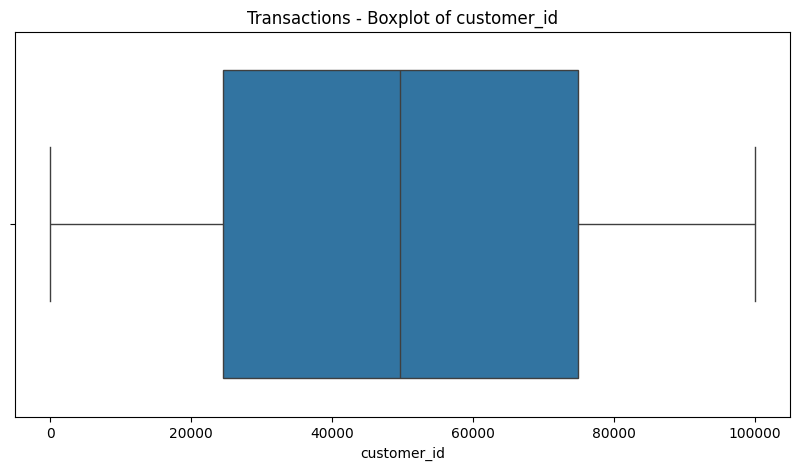

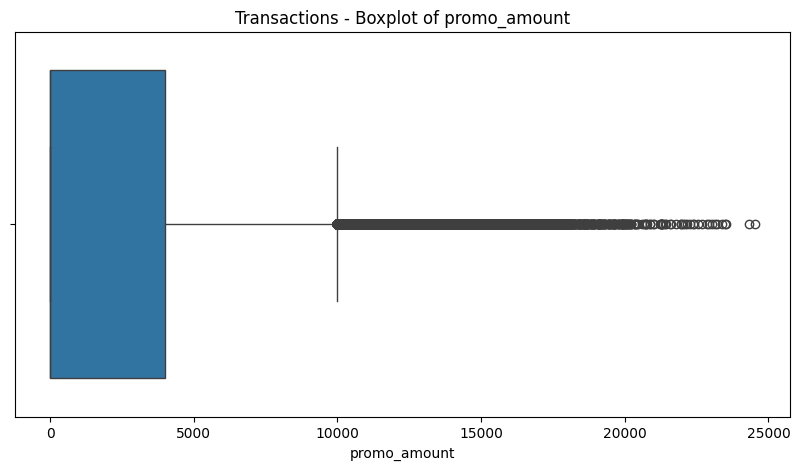

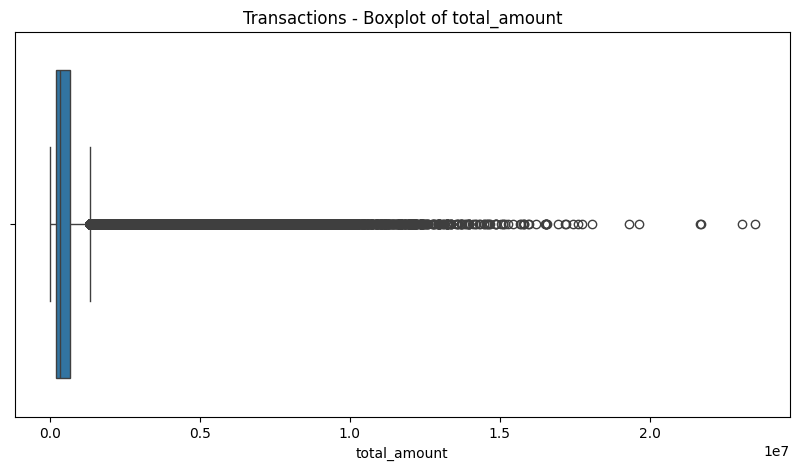

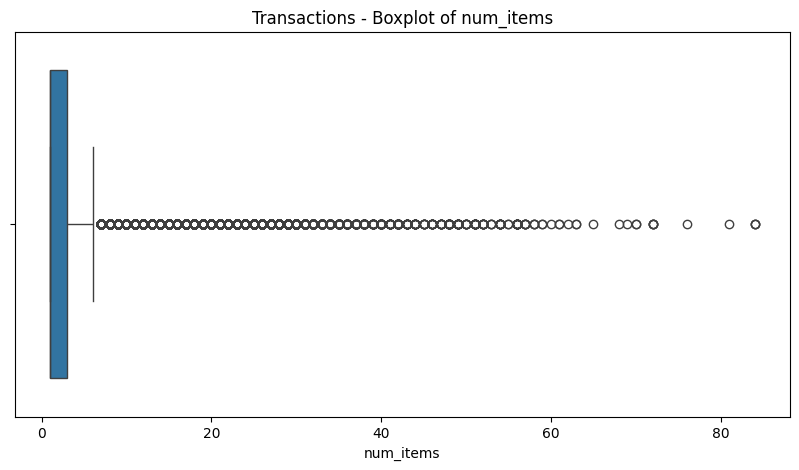

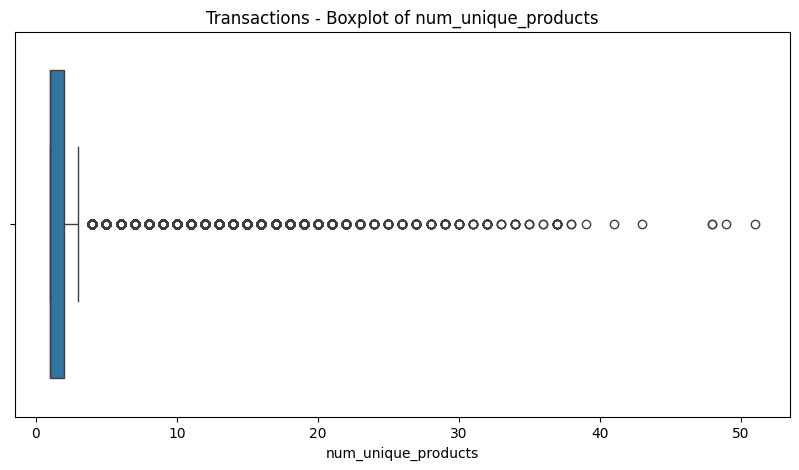

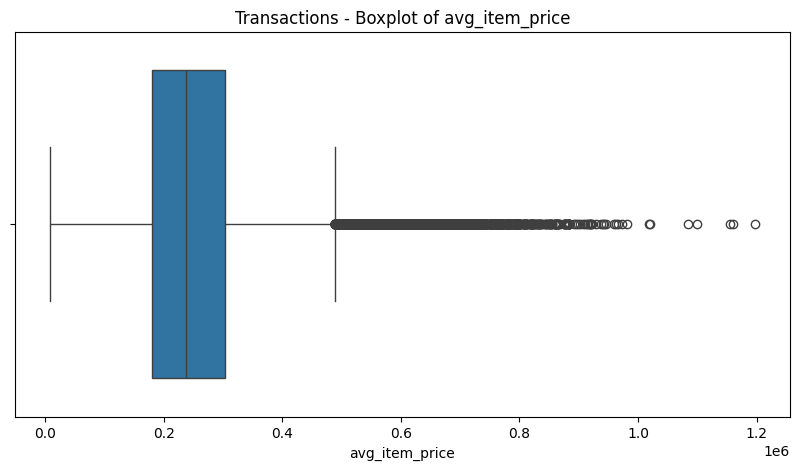


 3. Outlier Analysis for Products 


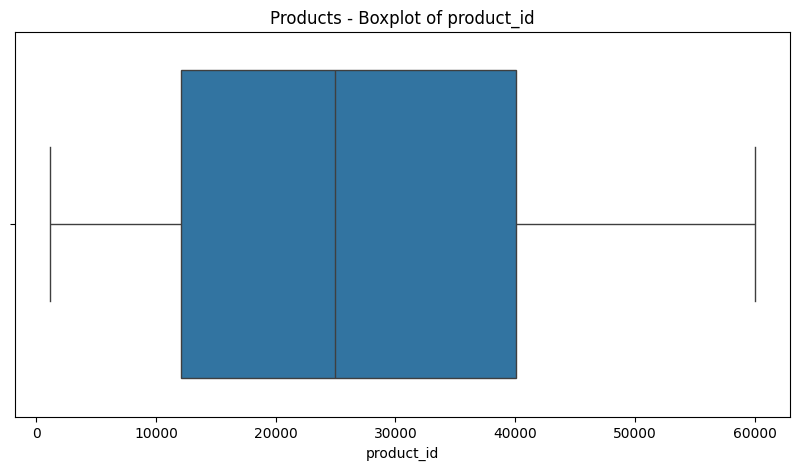


 3. Outlier Analysis for Customers 


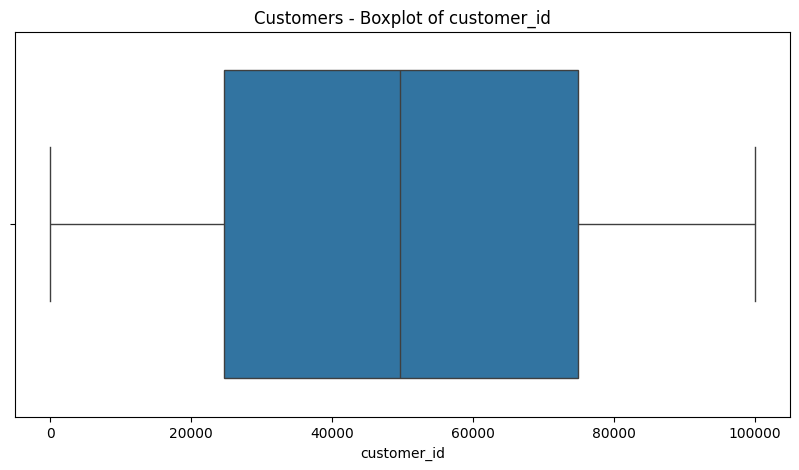


 3. Outlier Analysis for Clickstream 


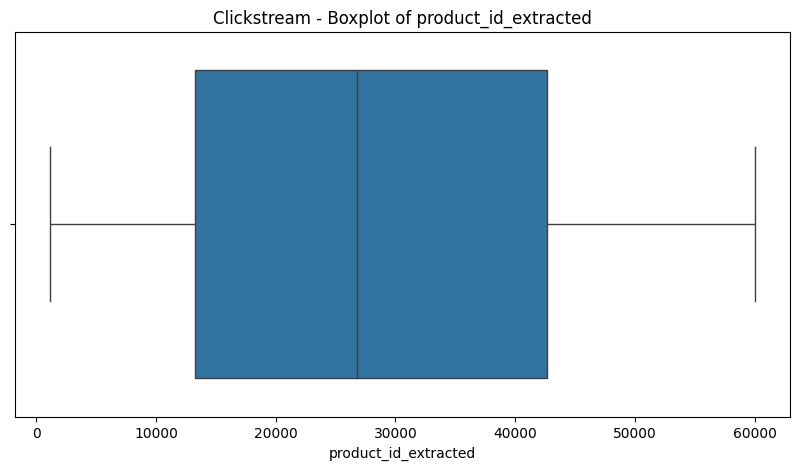

In [4]:
# PREPROCESSING_2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

filter_path = '/content/drive/MyDrive/KLTN_dataset_filter'

# Load parsed & cleaned DataFrames
df_transactions = pd.read_csv(os.path.join(filter_path, 'apparel_transactions_p2.csv'))
df_products = pd.read_csv(os.path.join(filter_path, 'apparel_products_p2.csv'))
df_customers = pd.read_csv(os.path.join(filter_path, 'apparel_customers_p2.csv'))
df_clickstream = pd.read_csv(os.path.join(filter_path, 'apparel_clickstream_p2.csv'))

print(" Loaded 4 parsed & cleaned files.")

# Thông tin chung
def basic_info(df, df_name):
    print(f"\n=== {df_name} TABLE ===")
    print(f"Shape: {df.shape}")
    print("Data types:")
    print(df.dtypes)
    print("Memory usage:", df.memory_usage(deep=True).sum(), "bytes")
    print("\nFirst 5 rows:")
    print(df.head())

basic_info(df_transactions, "Transactions")
basic_info(df_products, "Products")
basic_info(df_customers, "Customers")
basic_info(df_clickstream, "Clickstream")

# Missing Values
def check_missing_values(df, df_name):
    missing_table = df.isnull().sum()
    missing_table = missing_table[missing_table > 0]
    print(f"\n 1. Missing Values in {df_name} ")
    if missing_table.empty:
        print("No missing values.")
    else:
        print(missing_table)

check_missing_values(df_transactions, "Transactions")
check_missing_values(df_products, "Products")
check_missing_values(df_customers, "Customers")
check_missing_values(df_clickstream, "Clickstream")


# 3. Duplicate Rows
def check_duplicates(df, df_name):
    duplicates = df.duplicated().sum()
    print(f"\n 2. Duplicate Rows in {df_name} ")
    print(f"Number of duplicate rows: {duplicates}")

check_duplicates(df_transactions, "Transactions")
check_duplicates(df_products, "Products")
check_duplicates(df_customers, "Customers")
check_duplicates(df_clickstream, "Clickstream")


# 4. Outliers (numeric features only)
def check_outliers(df, df_name):
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    print(f"\n 3. Outlier Analysis for {df_name} ")
    if len(numeric_cols) == 0:
        print("No numeric columns to analyze.")
        return
    for col in numeric_cols:
        plt.figure(figsize=(10,5))
        sns.boxplot(x=df[col])
        plt.title(f'{df_name} - Boxplot of {col}')
        plt.xlabel(col)
        plt.show()

check_outliers(df_transactions, "Transactions")
check_outliers(df_products, "Products")
check_outliers(df_customers, "Customers")
check_outliers(df_clickstream, "Clickstream")

In [5]:
# TASK 1 FEATURE + TARGET CREATION (binary, target: will_purchase_in_next_30_days)
import os
import pandas as pd
import numpy as np
from google.colab import drive
# --- 0. Đường dẫn (chỉnh nếu cần) ---
# Tải và kết nối Google Drive
drive.mount('/content/drive')
filter_path = '/content/drive/MyDrive/KLTN_dataset_filter'
# --- 1. Load các file ---
try:
    df_transactions = pd.read_csv(os.path.join(filter_path, 'apparel_transactions_p2.csv'))
    print("Loaded transactions:", df_transactions.shape)
except FileNotFoundError:
    raise FileNotFoundError("Không tìm thấy apparel_transactions_p2.csv ở filter_path. Kiểm tra đường dẫn/file.")
df_products = None
df_customers = None
df_clickstream = None
try:
    df_products = pd.read_csv(os.path.join(filter_path, 'apparel_products_p2.csv'))
    print("Loaded products:", df_products.shape)
except FileNotFoundError:
    print("Warning: sản phẩm file không tìm thấy. Một số feature sản phẩm sẽ bị bỏ qua.")
try:
    df_customers = pd.read_csv(os.path.join(filter_path, 'apparel_customers_p2.csv'))
    print("Loaded customers:", df_customers.shape)
except FileNotFoundError:
    print("Warning: customers file không tìm thấy. Chỉ dùng customer_id từ transactions nếu có.")
try:
    df_clickstream = pd.read_csv(os.path.join(filter_path, 'apparel_clickstream_p2.csv'))
    print("Loaded clickstream:", df_clickstream.shape)
except FileNotFoundError:
    print("Warning: clickstream file không tìm thấy. Một số behavioral features sẽ bị bỏ qua.")
# --- 2. Convert datetime ---
df_transactions['created_at'] = pd.to_datetime(df_transactions['created_at'], errors='coerce', utc=True).dt.tz_localize(None)
if df_customers is not None:
    df_customers['birthdate'] = pd.to_datetime(df_customers['birthdate'], errors='coerce')
    df_customers['first_join_date'] = pd.to_datetime(df_customers['first_join_date'], errors='coerce')
if df_clickstream is not None:
    df_clickstream['event_time'] = pd.to_datetime(df_clickstream['event_time'], errors='coerce', utc=True).dt.tz_localize(None)
# --- 3. Kiểm tra/chuẩn hóa kiểu id ---
# đảm bảo customer_id là int (nếu có)
if 'customer_id' in df_transactions.columns:
    df_transactions['customer_id'] = df_transactions['customer_id'].astype(int)
if df_customers is not None and 'customer_id' in df_customers.columns:
    df_customers['customer_id'] = df_customers['customer_id'].astype(int)
# --- 4. Tạo session-level behaviour features từ clickstream (nếu có) ---
# Lấy thống kê event counts theo session (VIEW_PRODUCT, ADD_TO_CART, ...)
session_feats = None
if df_clickstream is not None:
    # event counts per session (pivot)
    # normalize event_name strings (uppercase trimming)
    df_clickstream['event_name'] = df_clickstream['event_name'].astype(str).str.strip().str.upper()
    # count event types per session
    evt_counts = pd.crosstab(df_clickstream['session_id'], df_clickstream['event_name'])
    evt_counts.columns = ['session_evt_' + str(c).lower() for c in evt_counts.columns]
    evt_counts = evt_counts.reset_index()
    # session unique product count + session duration
    sess_prod_nunique = (
        df_clickstream.dropna(subset=['product_id_extracted'])
                     .groupby('session_id')['product_id_extracted']
                     .nunique()
                     .reset_index(name='session_unique_products')
    )
    sess_time = df_clickstream.groupby('session_id').agg(
        session_time_min=('event_time','min'),
        session_time_max=('event_time','max'),
    ).reset_index()
    sess_time['session_duration_sec'] = (sess_time['session_time_max'] - sess_time['session_time_min']).dt.total_seconds().fillna(0)
    # merge all session features
    session_feats = evt_counts.merge(sess_prod_nunique, on='session_id', how='left').merge(
        sess_time[['session_id','session_duration_sec']], on='session_id', how='left'
    )
    # fillna zeros
    session_feats = session_feats.fillna(0)
# --- 5. Gán session features vào df_transactions (kết hợp theo session_id) ---
if session_feats is not None and 'session_id' in df_transactions.columns:
    df_transactions = df_transactions.merge(session_feats, on='session_id', how='left')
    # nếu session nào không khớp sẽ NaN -> gán 0
    session_cols = [c for c in session_feats.columns if c != 'session_id']
    df_transactions[session_cols] = df_transactions[session_cols].fillna(0)
else:
    # nếu không có clickstream hoặc session_id mismatch thì tạo cột 0 để tránh lỗi downstream
    default_session_cols = [
        'session_evt_view_product','session_evt_add_to_cart','session_evt_homepage',
        'session_unique_products','session_duration_sec'
    ]
    # chỉ tạo những cột chưa tồn tại
    for c in default_session_cols:
        if c not in df_transactions.columns:
            df_transactions[c] = 0
# --- 6. Sắp xếp và tạo các feature prior-only (RFM prior) ---
df_transactions = df_transactions.sort_values(['customer_id','created_at']).reset_index(drop=True)
g = df_transactions.groupby('customer_id')
# previous purchase date
df_transactions['prev_purchase_date'] = g['created_at'].shift(1)
# recency in days (NaN for first purchase)
df_transactions['recency_days'] = (df_transactions['created_at'] - df_transactions['prev_purchase_date']).dt.days
# frequency = number of previous purchases (0 for first purchase)
df_transactions['frequency'] = g.cumcount()
# cumulative spent prior to this txn (exclude current txn)
df_transactions['cum_spent_prior'] = g['total_amount'].cumsum().shift(1).fillna(0)
# total_spent_to_date (prior only)
df_transactions['total_spent_to_date'] = df_transactions['cum_spent_prior']
# nếu có cột num_unique_products (per transaction), có thể tạo cumulative sum (approx)
if 'num_unique_products' in df_transactions.columns:
    df_transactions['num_unique_products_cum'] = g['num_unique_products'].cumsum().shift(1).fillna(0)
# --- 7. (tuỳ chọn) favorite category per customer ---
# Nếu transactions -> product mapping tồn tại trước đó (vd df_transactions có product_id column),
# có thể lấy favorite category theo lịch sử. Nếu không, ta thử suy ra từ clickstream session-product mapping.
favorite_cat_per_customer = None
if ('product_id' in df_transactions.columns) and (df_products is not None):
    tx_prod = df_transactions.merge(df_products[['product_id','articleType']], on='product_id', how='left')
    favorite_cat_per_customer = tx_prod.groupby('customer_id')['articleType'].agg(
        lambda s: s.mode().iloc[0] if len(s.dropna())>0 else np.nan
    ).reset_index(name='fav_articleType')
elif (df_clickstream is not None) and (df_products is not None):
    # attempt: map session->customer (for sessions that appear in transactions), then use clickstream product events
    session_customer = df_transactions[['session_id','customer_id']].drop_duplicates()
    cs_with_cust = df_clickstream.merge(session_customer, on='session_id', how='inner')
    # join product metadata
    if 'product_id_extracted' in cs_with_cust.columns:
        cs_with_cust = cs_with_cust.merge(df_products[['product_id','articleType']], left_on='product_id_extracted', right_on='product_id', how='left')
        favorite_cat_per_customer = cs_with_cust.groupby('customer_id')['articleType'].agg(
            lambda s: s.mode().iloc[0] if len(s.dropna())>0 else np.nan
        ).reset_index(name='fav_articleType')
if favorite_cat_per_customer is not None:
    df_transactions = df_transactions.merge(favorite_cat_per_customer, on='customer_id', how='left')
# --- 8. Tạo target: will_purchase_in_next_30_days (binary) theo logic proposal ---
df_transactions['next_purchase_date'] = g['created_at'].shift(-1)
df_transactions['days_to_next_purchase'] = (df_transactions['next_purchase_date'] - df_transactions['created_at']).dt.days
df_transactions['will_purchase_in_next_30_days'] = ((df_transactions['days_to_next_purchase'] <= 30) & (df_transactions['days_to_next_purchase'] >= 0)).astype(int)
# rows where next_purchase_date is NaT => days_to_next_purchase NaN => will_purchase_in_next_30_days = 0 (already handled by boolean op)
# --- 9. Chọn cột feature + target để lưu ---
task1_cols = [
    'customer_id','created_at',
    'recency_days','frequency','total_spent_to_date'
]
# add optional cols if exist
extra_cols = ['num_unique_products_cum','fav_articleType',
              'session_evt_view_product','session_evt_add_to_cart','session_unique_products',
              'session_duration_sec']
for c in extra_cols:
    if c in df_transactions.columns and c not in task1_cols:
        task1_cols.append(c)
task1_cols += ['days_to_next_purchase','will_purchase_in_next_30_days']
df_task1 = df_transactions[task1_cols].copy()
# --- 10. Lưu file CSV ---
output_path = os.path.join(filter_path, 'task1_features.csv')
df_task1.to_csv(output_path, index=False)
print("Saved Task1 features to:", output_path)
print("Task1 shape:", df_task1.shape)
print(df_task1.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded transactions: (462528, 10)
Loaded products: (21397, 5)
Loaded customers: (44263, 4)
Loaded clickstream: (6948248, 5)
Saved Task1 features to: /content/drive/MyDrive/KLTN_dataset_filter/task1_features.csv
Task1 shape: (462528, 12)
   customer_id                 created_at  recency_days  frequency  \
0            3 2018-10-20 19:07:54.844494           NaN          0   
1            3 2019-01-12 19:50:13.844494          84.0          1   
2            3 2019-02-09 20:49:55.844494          28.0          2   
3            3 2019-04-06 21:41:56.844494          56.0          3   
4            3 2019-05-04 21:21:00.844494          27.0          4   

   total_spent_to_date  num_unique_products_cum fav_articleType  \
0                  0.0                      0.0         Tshirts   
1             124932.0                      1.0         Tshirts   
2           

In [6]:
# TASK 2 FEATURE + TARGET CREATION (multi-class classification, target: most_purchased_category)
import os
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import gc
# --- 0. Đường dẫn (đã mount Drive) ---
filter_path = '/content/drive/MyDrive/KLTN_dataset_filter'
# --- 1. Load dữ liệu ---
df_transactions = pd.read_csv(os.path.join(filter_path, 'apparel_transactions_p2.csv'))
df_products     = pd.read_csv(os.path.join(filter_path, 'apparel_products_p2.csv'))
df_clickstream  = pd.read_csv(os.path.join(filter_path, 'apparel_clickstream_p2.csv'))
print("Transactions:", df_transactions.shape)
print("Products:", df_products.shape)
print("Clickstream:", df_clickstream.shape)
# --- 2. Datetime & cleaning clickstream events (only ADD_TO_CART) ---
df_transactions['created_at'] = pd.to_datetime(df_transactions['created_at'], errors='coerce')
df_clickstream['event_time']   = pd.to_datetime(df_clickstream['event_time'], errors='coerce')
# Keep only ADD_TO_CART (you requested) and non-null product ids
cs = df_clickstream[df_clickstream['event_name'].str.upper() == 'ADD_TO_CART'].copy()
cs = cs[cs['product_id_extracted'].notna()].copy()
# normalize to int product id where possible
cs['product_id_extracted'] = pd.to_numeric(cs['product_id_extracted'], errors='coerce')
cs = cs.dropna(subset=['product_id_extracted']).copy()
cs['product_id_extracted'] = cs['product_id_extracted'].astype(int)
# reduce columns
cs = cs[['session_id','event_time','product_id_extracted']]
# --- 3. Build lookup: for each session, list transaction indices and times (sorted) ---
# Keep transactions with session_id present (to reduce work)
sessions_with_txn = df_transactions['session_id'].dropna().unique()
cs = cs[cs['session_id'].isin(sessions_with_txn)].copy()
print("Filtered clickstream rows (sessions in transactions & have product):", cs.shape)
# sort transactions by session_id, created_at and keep original index
df_txn = df_transactions.reset_index().rename(columns={'index':'txn_index'})  # txn_index is original row index
df_txn = df_txn.sort_values(['session_id','created_at']).reset_index(drop=True)
# Build dict: session_id -> (txn_idx_array, txn_time_array)
session_txn_info = {}
for session_id, grp in df_txn.groupby('session_id', sort=False):
    idxs = grp['txn_index'].values    # original indices
    times = grp['created_at'].values  # numpy datetime64
    session_txn_info[session_id] = (idxs, times)
# --- 4. Map click events -> transaction index (txn_index) using searchsorted (first txn with created_at >= event_time) ---
txn_to_product_ids = defaultdict(list)  # key: txn_index (original index), value: list of product_ids
# iterate clickstream grouped by session to be efficient
for session_id, cs_grp in cs.groupby('session_id', sort=False):
    if session_id not in session_txn_info:
        continue
    txn_idxs, txn_times = session_txn_info[session_id]
    evt_times = cs_grp['event_time'].values
    evt_pids  = cs_grp['product_id_extracted'].values
    # use searchsorted to find, for each event_time, first txn_time >= event_time
    pos = np.searchsorted(txn_times, evt_times, side='left')
    for p, pid in zip(pos, evt_pids):
        if p < len(txn_idxs):
            txn_global_idx = int(txn_idxs[p])
            txn_to_product_ids[txn_global_idx].append(int(pid))
# free some memory
del cs
gc.collect()
# --- 5. Aggregate mapped product_ids back into df_txn (by txn_index) ---
# create columns product_ids_list (may be NaN) and articleTypes_list
prod_map = df_products.set_index('product_id')['articleType'].to_dict()
# prepare lists aligned with original df_transactions index
n_txn = df_transactions.shape[0]
mapped_product_ids = [np.nan] * n_txn
mapped_article_types = [np.nan] * n_txn
for txn_idx, pid_list in txn_to_product_ids.items():
    # txn_idx refers to original df_transactions.index (since we used txn_index originally)
    mapped_product_ids[txn_idx] = pid_list
    # map to articleTypes (drop Nones)
    types = [prod_map.get(pid, np.nan) for pid in pid_list]
    types = [t for t in types if pd.notna(t)]
    mapped_article_types[txn_idx] = types if len(types)>0 else np.nan
# attach to df_transactions (use original ordering)
df_transactions['mapped_product_ids'] = mapped_product_ids
df_transactions['mapped_article_types'] = mapped_article_types
print("Fraction txns with mapped products:", df_transactions['mapped_article_types'].notna().mean())
# --- 6. For simplicity: derive a single representative articleType per transaction ---
# Options: (A) mode (most frequent) among mapped types; (B) if multiple types equal, choose most recent in order of events (we don't have event order here); we'll use mode then fallback to first.
def mode_or_first(lst):
    if isinstance(lst, list) and len(lst)>0:
        c = Counter(lst)
        most_common = c.most_common()
        top_count = most_common[0][1]
        candidates = [k for k,v in most_common if v==top_count]
        # tie-break: choose the one that appears last in list (approx most recent)
        for v in reversed(lst):
            if v in candidates:
                return v
        return candidates[0]
    return np.nan
df_transactions['articleType_txn_mode'] = df_transactions['mapped_article_types'].apply(lambda x: mode_or_first(x))
# --- 7. Now prepare ordered per-customer list and compute features + target with clear loop (robust) ---
df_transactions['created_at'] = pd.to_datetime(df_transactions['created_at'])
df_transactions = df_transactions.sort_values(['customer_id','created_at']).reset_index(drop=False).rename(columns={'index':'orig_index'})
# orig_index: original row index in previous df_transactions read
out_rows = []  # accumulate feature+target rows (ordered same as df_transactions rows after sort)
# We'll iterate customer by customer
for cust_id, grp in df_transactions.groupby('customer_id', sort=False):
    grp = grp.sort_values('created_at').reset_index(drop=True)
    m_types = grp['articleType_txn_mode'].tolist()       # representative type per txn (may be nan)
    all_types_list = grp['mapped_article_types'].tolist() # lists or NaN
    times = grp['created_at'].tolist()
    totals = grp['total_amount'].tolist()
    # maintain prior stats
    seen_types = []
    seen_set = set()
    cum_spent = 0.0
    for i in range(len(grp)):
        obs_time = times[i]
        # features prior-only
        prior_count = i  # number of previous txns
        total_spent_prior = cum_spent
        recency_days = (obs_time - times[i-1]).days if i>0 else np.nan
        recent_category = m_types[i-1] if i>0 else np.nan
        # num unique prior (count distinct seen_set)
        num_unique_prior = len(seen_set)
        # compute target: aggregate ALL articleTypes in future txns within 30 days
        t_end = obs_time + pd.Timedelta(days=30)
        # scan future txns j>i with times[j] <= t_end
        counts = Counter()
        recency_sequence = []  # flatten order to tie-break by last occurrence
        for j in range(i+1, len(grp)):
            if times[j] > t_end:
                break
            alist = all_types_list[j]
            if isinstance(alist, list):
                for at in alist:
                    counts[at] += 1
                    recency_sequence.append(at)
        if len(counts)==0:
            target = np.nan
        else:
            max_count = max(counts.values())
            candidates = [k for k,v in counts.items() if v==max_count]
            if len(candidates)==1:
                target = candidates[0]
            else:
                # tie-break: pick last occurrence in recency_sequence among candidates
                pick = None
                for v in reversed(recency_sequence):
                    if v in candidates:
                        pick = v
                        break
                target = pick if pick is not None else candidates[0]
        # append row result (we include original txn index to later re-align if needed)
        out_rows.append({
            'orig_index': grp.at[i,'orig_index'],
            'customer_id': cust_id,
            'created_at': obs_time,
            'articleType_txn_mode': m_types[i],
            'prior_purchase_count': prior_count,
            'total_spent_prior': total_spent_prior,
            'recency_days': recency_days,
            'recent_category': recent_category,
            'num_unique_categories_prior': num_unique_prior,
            'most_purchased_category': target
        })
        # update seen & cum_spent after processing this txn (so prior-only)
        # incorporate article types from this txn into seen_set
        cur_types = all_types_list[i]
        if isinstance(cur_types, list):
            for t in cur_types:
                if pd.notna(t):
                    seen_set.add(t)
        cum_spent += totals[i]
# make df from out_rows
df_task2 = pd.DataFrame(out_rows)
# keep only rows that have target (labelled)
df_task2_labeled = df_task2[df_task2['most_purchased_category'].notna()].reset_index(drop=True)
print("Total transactions:", len(df_transactions))
print("Mapped transactions with products:", df_transactions['mapped_article_types'].notna().sum())
print("Labeled rows for Task2:", df_task2_labeled.shape)
# --- 8. Save file ---
out_path = os.path.join(filter_path, 'task2_features_mapped.csv')
df_task2_labeled.to_csv(out_path, index=False)
print("Saved labelled Task2 file to:", out_path)


Transactions: (462528, 10)
Products: (21397, 5)
Clickstream: (6948248, 5)
Filtered clickstream rows (sessions in transactions & have product): (1182092, 3)
Fraction txns with mapped products: 0.9999956759374568
Total transactions: 462528
Mapped transactions with products: 462526
Labeled rows for Task2: (199419, 10)
Saved labelled Task2 file to: /content/drive/MyDrive/KLTN_dataset_filter/task2_features_mapped.csv
